Libraries loaded.
  1/397 blocks fetched...
  41/397 blocks fetched...
  81/397 blocks fetched...
  121/397 blocks fetched...
  161/397 blocks fetched...
  201/397 blocks fetched...
  241/397 blocks fetched...
  281/397 blocks fetched...
  321/397 blocks fetched...
  361/397 blocks fetched...

1985 trading days loaded.
Mean daily P&L : 15.68 €/MWh
Std deviation  : 44.20 €/MWh
Skewness       : 1.930
Kurtosis       : 11.333


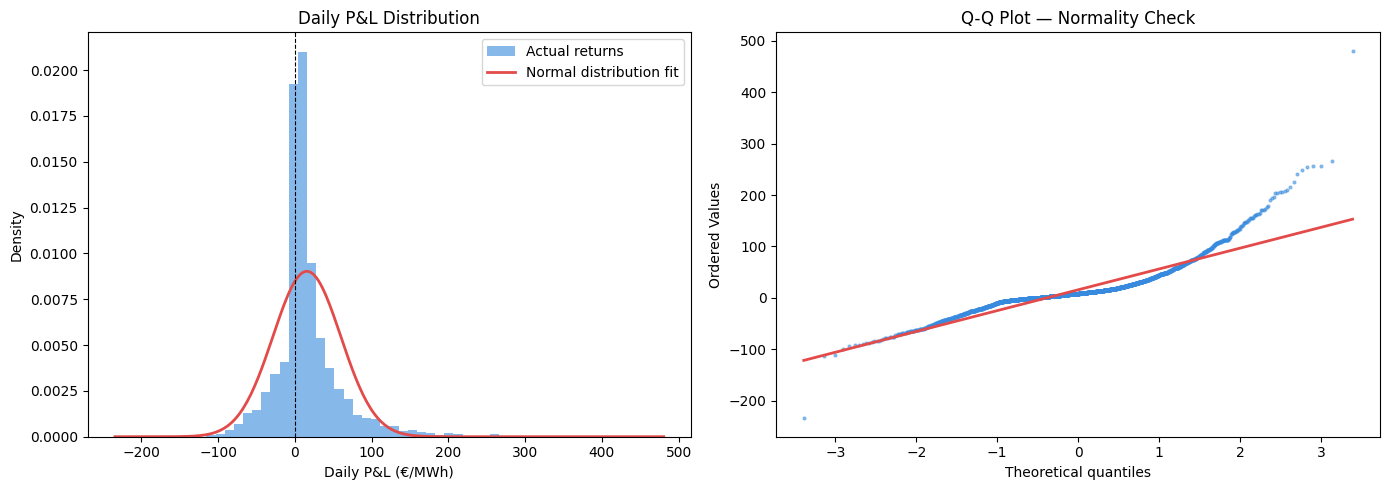

Chart saved.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

# ── Rebuild daily P&L from SMARD data ───────────────────────
# (run this if starting fresh, otherwise reuse bt from Project 2)
import requests

INDEX_URL = 'https://www.smard.de/app/chart_data/4169/DE/index_hour.json'
timestamps = requests.get(INDEX_URL).json()['timestamps']
blocks     = sorted(timestamps)

records = []
for i, ts in enumerate(blocks):
    url  = f'https://www.smard.de/app/chart_data/4169/DE/4169_DE_hour_{ts}.json'
    data = requests.get(url).json().get('series', [])
    for entry in data:
        if entry[1] is not None:
            records.append({
                'timestamp': pd.to_datetime(entry[0], unit='ms', utc=True),
                'price':     entry[1]
            })
    if i % 40 == 0:
        print(f'  {i+1}/{len(blocks)} blocks fetched...')

df = (pd.DataFrame(records)
        .drop_duplicates('timestamp')
        .sort_values('timestamp')
        .set_index('timestamp')
        .tz_convert('Europe/Berlin'))
df = df[df['price'] > -500]
df['hour']    = df.index.hour
df['weekday'] = df.index.dayofweek
df['date']    = df.index.date

# ── Rebuild daily P&L (same strategy as Project 2) ──────────
COST = 7.0
results = []

for date, day_data in df.groupby('date'):
    if len(day_data) < 20:
        continue
    if pd.Timestamp(date).dayofweek >= 5:
        continue

    buy  = day_data[day_data['hour'].between(1, 5)]['price'].mean()
    sell = day_data[day_data['hour'].between(9, 19)]['price'].mean()
    results.append({
        'date':    date,
        'net_pnl': round(sell - buy - COST, 2)
    })

bt = pd.DataFrame(results)
bt['date'] = pd.to_datetime(bt['date'])
returns    = bt['net_pnl'].values

print(f'\n{len(bt)} trading days loaded.')
print(f'Mean daily P&L : {returns.mean():.2f} €/MWh')
print(f'Std deviation  : {returns.std():.2f} €/MWh')
print(f'Skewness       : {stats.skew(returns):.3f}')
print(f'Kurtosis       : {stats.kurtosis(returns):.3f}')

# ── Distribution plot ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + normal fit
x = np.linspace(returns.min(), returns.max(), 300)
mu, sigma = returns.mean(), returns.std()
axes[0].hist(returns, bins=60, density=True,
             color='#378ADD', alpha=0.6, label='Actual returns')
axes[0].plot(x, stats.norm.pdf(x, mu, sigma),
             color='#E24B4A', linewidth=2, label='Normal distribution fit')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Daily P&L Distribution')
axes[0].set_xlabel('Daily P&L (€/MWh)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Q-Q plot (normality check)
stats.probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot — Normality Check')
axes[1].get_lines()[0].set(color='#378ADD', markersize=2, alpha=0.5)
axes[1].get_lines()[1].set(color='#E24B4A', linewidth=2)

plt.tight_layout()
plt.savefig('return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

  Method                 Conf.    VaR (€/MWh)      CVaR (€/MWh)
  Historical             90%         -24.62         -49.08
  Parametric             90%         -40.98         -61.90
  Monte Carlo            90%         -41.45         -62.31
-----------------------------------------------------------------
  Historical             95%         -43.28         -64.99
  Parametric             95%         -57.03         -75.51
  Monte Carlo            95%         -57.48         -76.07
-----------------------------------------------------------------
  Historical             99%         -76.86         -95.58
  Parametric             99%         -87.16        -102.14
  Monte Carlo            99%         -86.90        -103.54
-----------------------------------------------------------------


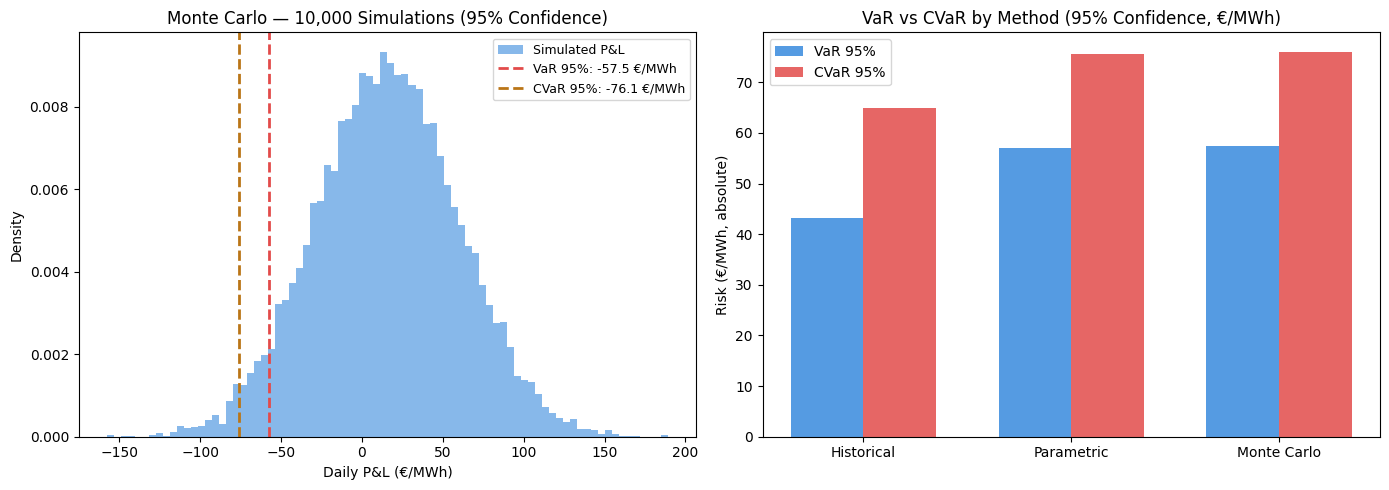

Chart saved.


In [2]:
# ── Confidence levels ────────────────────────────────────────
CONFIDENCE_LEVELS = [0.90, 0.95, 0.99]

# ── Method 1: Historical Simulation ─────────────────────────
def historical_var_cvar(returns, confidence):
    var  = np.percentile(returns, (1 - confidence) * 100)
    cvar = returns[returns <= var].mean()
    return var, cvar

# ── Method 2: Parametric (Gaussian) ─────────────────────────
def parametric_var_cvar(returns, confidence):
    mu, sigma = returns.mean(), returns.std()
    var  = stats.norm.ppf(1 - confidence, mu, sigma)
    cvar = mu - sigma * stats.norm.pdf(stats.norm.ppf(confidence)) / (1 - confidence)
    return var, cvar

# ── Method 3: Monte Carlo Simulation ────────────────────────
def monte_carlo_var_cvar(returns, confidence, n_sim=10_000, horizon=1):
    np.random.seed(42)
    mu, sigma = returns.mean(), returns.std()
    simulated = np.random.normal(mu, sigma, (n_sim, horizon)).sum(axis=1)
    var  = np.percentile(simulated, (1 - confidence) * 100)
    cvar = simulated[simulated <= var].mean()
    return var, cvar, simulated

# ── Results table ────────────────────────────────────────────
print('=' * 65)
print(f'  {"Method":<22} {"Conf.":<8} {"VaR (€/MWh)":<16} {"CVaR (€/MWh)"}')
print('=' * 65)

results_table = []

for conf in CONFIDENCE_LEVELS:
    h_var, h_cvar   = historical_var_cvar(returns, conf)
    p_var, p_cvar   = parametric_var_cvar(returns, conf)
    mc_var, mc_cvar, mc_sim = monte_carlo_var_cvar(returns, conf)

    for method, var, cvar in [
        ('Historical',  h_var, h_cvar),
        ('Parametric',  p_var, p_cvar),
        ('Monte Carlo', mc_var, mc_cvar),
    ]:
        print(f'  {method:<22} {conf*100:.0f}%     {var:>10.2f}     {cvar:>10.2f}')
        results_table.append({
            'method': method, 'confidence': conf,
            'var': var, 'cvar': cvar
        })
    print('-' * 65)

# ── Monte Carlo distribution plot ───────────────────────────
mc_var_95,  mc_cvar_95,  mc_sim_95  = monte_carlo_var_cvar(returns, 0.95)
mc_var_99,  mc_cvar_99,  mc_sim_99  = monte_carlo_var_cvar(returns, 0.99)
h_var_95,   h_cvar_95   = historical_var_cvar(returns, 0.95)
h_var_99,   h_cvar_99   = historical_var_cvar(returns, 0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monte Carlo — 95% confidence
axes[0].hist(mc_sim_95, bins=80, density=True,
             color='#378ADD', alpha=0.6, label='Simulated P&L')
axes[0].axvline(mc_var_95,  color='#E24B4A', linewidth=2,
                linestyle='--', label=f'VaR 95%: {mc_var_95:.1f} €/MWh')
axes[0].axvline(mc_cvar_95, color='#BA7517', linewidth=2,
                linestyle='--', label=f'CVaR 95%: {mc_cvar_95:.1f} €/MWh')
axes[0].set_title('Monte Carlo — 10,000 Simulations (95% Confidence)')
axes[0].set_xlabel('Daily P&L (€/MWh)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Historical vs Monte Carlo VaR comparison
methods  = ['Historical', 'Parametric', 'Monte Carlo']
var_95   = [h_var_95, parametric_var_cvar(returns, 0.95)[0], mc_var_95]
cvar_95  = [h_cvar_95, parametric_var_cvar(returns, 0.95)[1], mc_cvar_95]
x        = np.arange(len(methods))
width    = 0.35

axes[1].bar(x - width/2, [abs(v) for v in var_95],  width,
            label='VaR 95%',  color='#378ADD', alpha=0.85)
axes[1].bar(x + width/2, [abs(v) for v in cvar_95], width,
            label='CVaR 95%', color='#E24B4A', alpha=0.85)
axes[1].set_title('VaR vs CVaR by Method (95% Confidence, €/MWh)')
axes[1].set_ylabel('Risk (€/MWh, absolute)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods)
axes[1].legend()

plt.tight_layout()
plt.savefig('var_cvar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

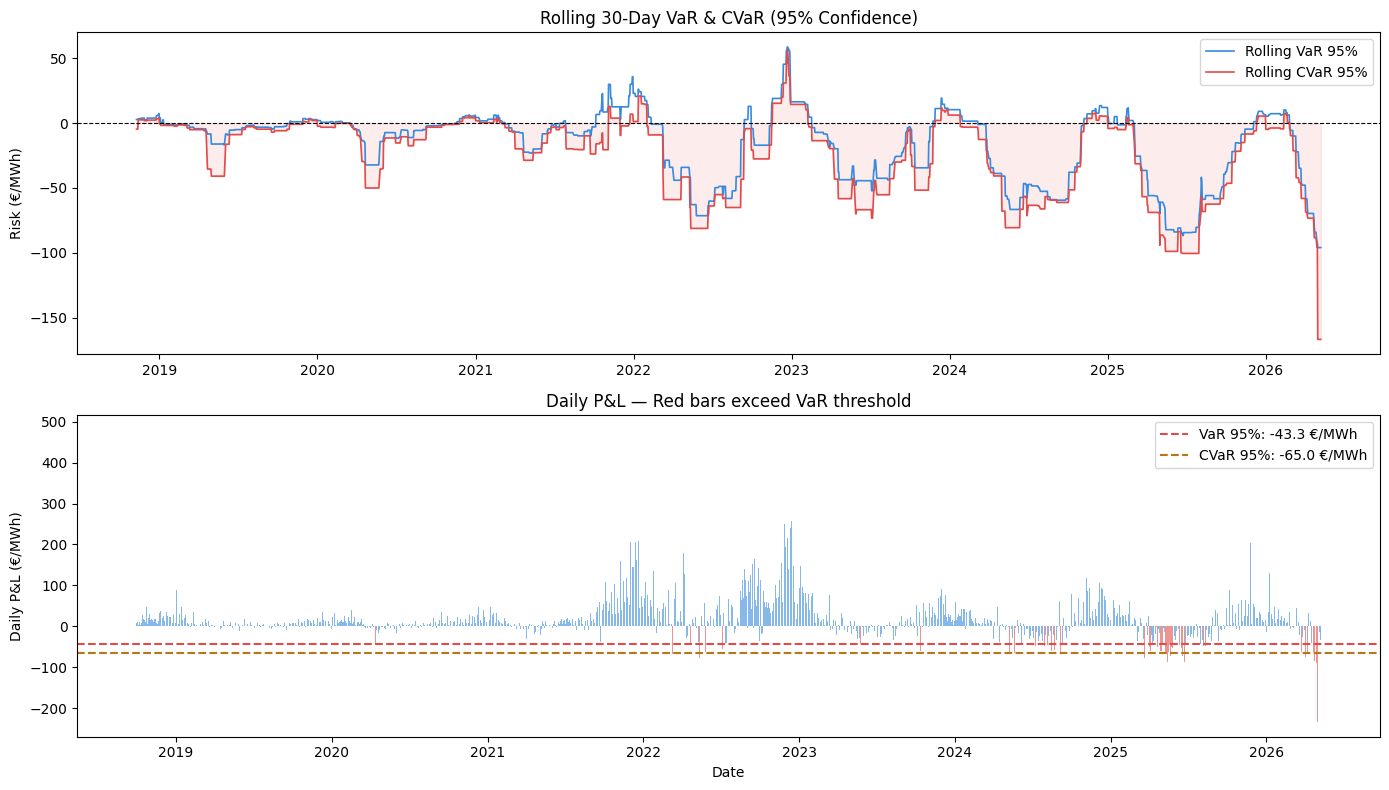

  VaR / CVaR RISK REPORT
  Method            : Historical Simulation
  Data              : 1,985 trading days
  Mean daily P&L    : 15.68 €/MWh
  VaR  90%          : -24.62 €/MWh
  VaR  95%          : -43.28 €/MWh
  VaR  99%          : -76.86 €/MWh
  CVaR 95%          : -64.99 €/MWh
  CVaR 99%          : -95.58 €/MWh
  VaR breach rate   : 5.0%
  Monte Carlo sims  : 10,000


In [3]:
# ── Rolling 30-day VaR ───────────────────────────────────────
window = 30
rolling_var  = [np.percentile(returns[max(0,i-window):i], 5)
                for i in range(window, len(returns)+1)]
rolling_cvar = [returns[max(0,i-window):i][
                    returns[max(0,i-window):i] <=
                    np.percentile(returns[max(0,i-window):i], 5)
                ].mean()
                for i in range(window, len(returns)+1)]

dates_rolling = bt['date'].iloc[window-1:].values

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Rolling VaR / CVaR over time
axes[0].plot(dates_rolling, rolling_var,
             color='#378ADD', linewidth=1.2, label='Rolling VaR 95%')
axes[0].plot(dates_rolling, rolling_cvar,
             color='#E24B4A', linewidth=1.2, label='Rolling CVaR 95%')
axes[0].fill_between(dates_rolling, rolling_cvar, 0,
                     alpha=0.1, color='#E24B4A')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Rolling 30-Day VaR & CVaR (95% Confidence)')
axes[0].set_ylabel('Risk (€/MWh)')
axes[0].legend()

# Daily P&L with VaR threshold
h_var_95, h_cvar_95 = historical_var_cvar(returns, 0.95)
axes[1].bar(bt['date'], bt['net_pnl'],
            color=['#E24B4A' if p < h_var_95 else '#378ADD'
                   for p in bt['net_pnl']],
            alpha=0.6, width=1)
axes[1].axhline(h_var_95,  color='#E24B4A', linewidth=1.5,
                linestyle='--', label=f'VaR 95%: {h_var_95:.1f} €/MWh')
axes[1].axhline(h_cvar_95, color='#BA7517', linewidth=1.5,
                linestyle='--', label=f'CVaR 95%: {h_cvar_95:.1f} €/MWh')
axes[1].set_title('Daily P&L — Red bars exceed VaR threshold')
axes[1].set_ylabel('Daily P&L (€/MWh)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.savefig('rolling_var_cvar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final summary ────────────────────────────────────────────
h_var_99, h_cvar_99 = historical_var_cvar(returns, 0.99)
breach_rate = (returns < h_var_95).mean() * 100

print('=' * 50)
print('  VaR / CVaR RISK REPORT')
print('=' * 50)
print(f'  Method            : Historical Simulation')
print(f'  Data              : 1,985 trading days')
print(f'  Mean daily P&L    : {returns.mean():.2f} €/MWh')
print(f'  VaR  90%          : {historical_var_cvar(returns, 0.90)[0]:.2f} €/MWh')
print(f'  VaR  95%          : {h_var_95:.2f} €/MWh')
print(f'  VaR  99%          : {h_var_99:.2f} €/MWh')
print(f'  CVaR 95%          : {h_cvar_95:.2f} €/MWh')
print(f'  CVaR 99%          : {h_cvar_99:.2f} €/MWh')
print(f'  VaR breach rate   : {breach_rate:.1f}%')
print(f'  Monte Carlo sims  : 10,000')
print('=' * 50)
